# Dimensionality Reduction on MNIST 8x8

This notebook shows how to flatten digit images, classify them, and compare PCA with t-SNE for visualization.

**Loading the data**

Start by loading the built-in handwritten digit dataset and checking its size.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn import metrics

digits = datasets.load_digits()
print("Shape", digits.images.shape)

Shape (1797, 8, 8)


In [2]:
digits.target

array([0, 1, 2, ..., 8, 9, 8], shape=(1797,))

**Showing the data**

Plot a few digits so you can see the appearance of the classes before any preprocessing.

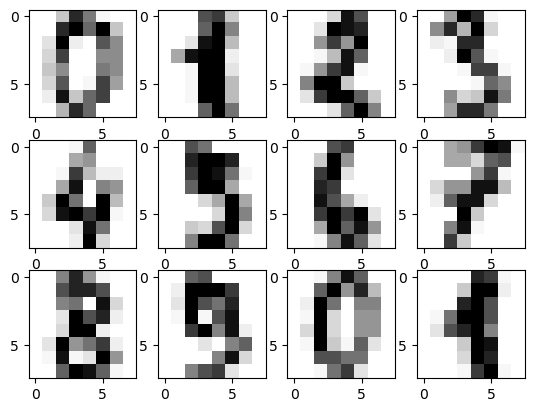

In [3]:
example_images = tuple(zip(digits.images[:12], digits.target))
# Create a figure showing some images
for i, (idata, ilabel) in enumerate(example_images):
    sub = plt.subplot(3, 4, i+1)
    sub.imshow(idata, cmap='Greys')

**Flatten and splitting the data**

Convert each image into a feature vector and split the data into training and test sets.

In [4]:
# Flatten the structure of the array using reshape
# -1 tells NumPy to determine the row size from the
# length of the inner dimensions.
mnist_mldata = digits.images.reshape(len(digits.images), 8*8)
print("Flatten images", mnist_mldata.shape)

Flatten images (1797, 64)


In [5]:
# Step 1: Split data into training/testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    mnist_mldata, digits.target, test_size=0.3, shuffle=False)
print("Train", X_train.shape[0],  "Test",  X_test.shape[0])

Train 1257 Test 540


**Use SVC to classify the images**

Train a support vector classifier on the raw pixel features as a baseline.

In [6]:
from sklearn.svm import SVC

# Step 2: Initialize machine learning algorithm
svm = SVC()

# Step 3: Train model instance on the data
svm.fit(X_train, y_train)

print('SVM Results:')
print('   Accuarcy on training data: {:.3f}'.format(svm.score(X_train, y_train)))
print('   Accuarcy on test data    : {:.3f}'.format(svm.score(X_test, y_test)))

SVM Results:
   Accuarcy on training data: 0.997
   Accuarcy on test data    : 0.954


**Now Preprocess with PCA until we got 95% of the variance**

Reduce the digit data while keeping most of the variance, then train the classifier again.

In [11]:
from sklearn.decomposition import PCA 

pca = PCA(
    n_components=0.92, 
    whiten=True, 
    random_state=0)
pca.fit(X_train)

X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print("Old Shape", X_train.shape)
print("New Shape", X_train_pca.shape)

Old Shape (1257, 64)
New Shape (1257, 24)


In [12]:
from sklearn.svm import SVC

svm = SVC() 
svm.fit(X_train_pca, y_train)

print('SVM Results:')
print('   Accuarcy on training data: {:.3f}'.format(svm.score(X_train_pca, y_train)))
print('   Accuarcy on test data    : {:.3f}'.format(svm.score(X_test_pca, y_test)))

SVM Results:
   Accuarcy on training data: 1.000
   Accuarcy on test data    : 0.972


**Now scaling down to 2 Dimensions for vizualization**

Project the digits into two PCA dimensions so the classes can be plotted directly.

Old Shape (1257, 64)
New Shape (1257, 2)
Traingdata


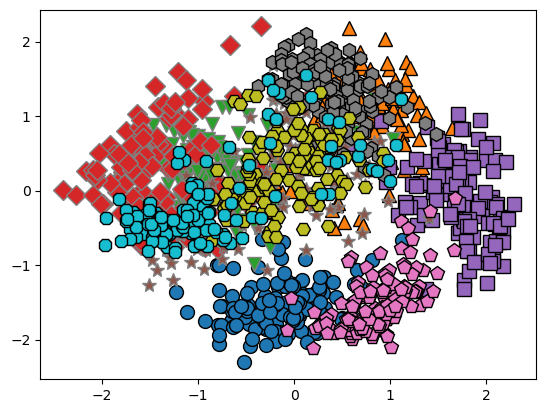

Testdata


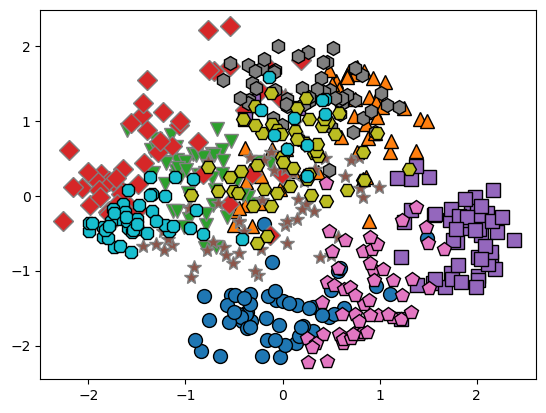

In [13]:
from sklearn.decomposition import PCA 
import mglearn

pca = PCA(n_components=2, 
          whiten=True, 
          random_state=0)
pca.fit(X_train)

X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print("Old Shape", X_train.shape)
print("New Shape", X_train_pca.shape)

print("Traingdata")
mglearn.discrete_scatter(X_train_pca[:,0],X_train_pca[:,1],y_train)
plt.show()

print("Testdata")
mglearn.discrete_scatter(X_test_pca[:,0],X_test_pca[:,1],y_test)
plt.show()



**For this Use-Case TSNE is great**

Use t-SNE as a comparison method when PCA does not separate the digits clearly enough.

In [16]:
from sklearn.manifold import TSNE
TSNE?

Init signature:
TSNE(
    n_components=2,
    *,
    perplexity=30.0,
    early_exaggeration=12.0,
    learning_rate='auto',
    max_iter=None,
    n_iter_without_progress=300,
    min_grad_norm=1e-07,
    metric='euclidean',
    metric_params=None,
    init='pca',
    verbose=0,
    random_state=None,
    method='barnes_hut',
    angle=0.5,
    n_jobs=None,
    n_iter='deprecated',
)
Docstring:     
T-distributed Stochastic Neighbor Embedding.

t-SNE [1] is a tool to visualize high-dimensional data. It converts
similarities between data points to joint probabilities and tries
to minimize the Kullback-Leibler divergence between the joint
probabilities of the low-dimensional embedding and the
high-dimensional data. t-SNE has a cost function that is not convex,
i.e. with different initializations we can get different results.

It is highly recommended to use another dimensionality reduction
method (e.g. PCA for dense data or TruncatedSVD for sparse data)
to reduce the number of dimension

Old Shape (1257, 64)
New Shape (1257, 2)
Done


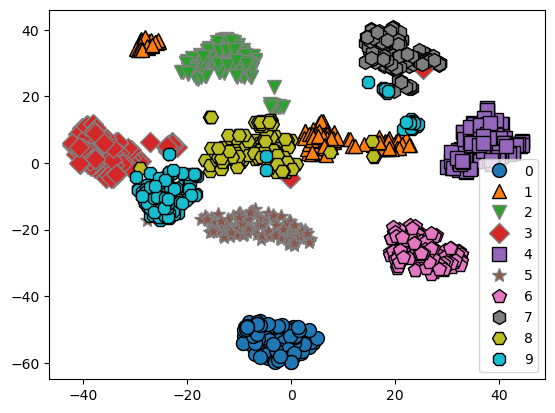

In [18]:
from sklearn.manifold import TSNE
import mglearn

tsne = TSNE(random_state=0)
X_train_tsne = tsne.fit_transform(X_train)

print("Old Shape", X_train.shape)
print("New Shape", X_train_tsne.shape)

mglearn.discrete_scatter(X_train_tsne[:,0],X_train_tsne[:,1],y_train)
plt.legend(loc=4)
print("Done")